In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

1387924


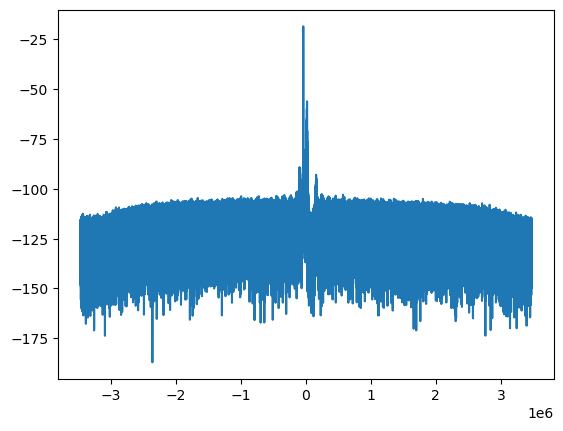

In [3]:
filepath = r'C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official\psd_current_9.0mA_coupling_4.796610e-04.csv'
df = pd.read_csv(filepath,skiprows=[2])

frequency = df['frequency_THz']
power = df['power_dB']
print(np.argmax(frequency))
plt.plot(frequency,power)
plt.show()

0
1387924


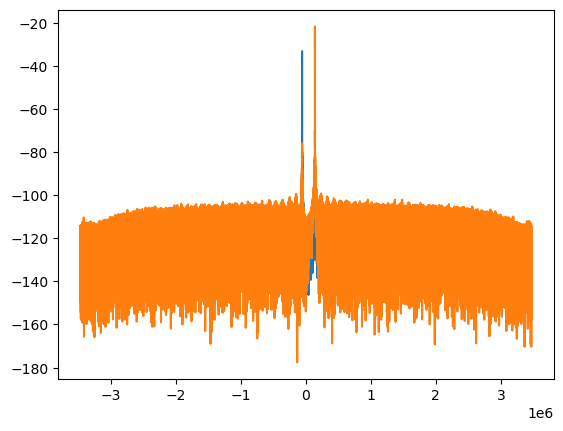

In [ ]:
filepath = r'C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\New\psd_current_9.0mA_coupling_1.030303e-04.csv'
df = pd.read_csv(filepath,skiprows=[2])

n_slice = 20

frequency = np.array(df['frequency_THz'])
frequency = np.mean(frequency[:(len(frequency)//n_slice)*n_slice].reshape(-1,3), axis=1)
power = np.array(df['power_dB'])
power = np.mean(power[:(len(power)//n_slice)*n_slice].reshape(-1,3), axis=1)
print(np.argmax(frequency))
plt.plot(frequency,power)
#plt.show()

filepath = r'C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official\psd_current_9.0mA_coupling_4.796610e-04.csv'
df = pd.read_csv(filepath,skiprows=[2])

frequency = df['frequency_THz']
power = df['power_dB']
print(np.argmax(frequency))
plt.plot(frequency,power)
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Path to your npz file
npz_path = r"C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official\linewidth_and_psd_coarse.npz"

# 2. Load cached data
if not os.path.isfile(npz_path):
    raise FileNotFoundError(f"Could not find {npz_path}")

data = np.load(npz_path)
freq_offset_GHz = data["freq_offset_GHz"]     # Array of shape (400,)
feedback_sorted = data["feedback_sorted"]     # Array of shape (n_runs,)
linewidth_sorted = data["linewidth_sorted"]   # Array of shape (n_runs,)
psd_dB_array = data["psd_dB_array"]           # Matrix of shape (400, n_runs)

n_runs = psd_dB_array.shape[1]
print(f"Loaded {n_runs} spectra.")

# 3. Create 10x10 subplot grid
cols = 10
rows = int(np.ceil(n_runs / cols))

fig, axes = plt.subplots(rows, cols, figsize=(22, 18), sharex=True, sharey=True)
axes_flat = axes.flatten()

# Determine global y-limits for consistency across plots
y_min = np.nanmin(psd_dB_array)
y_max = np.nanmax(psd_dB_array)

for i in range(n_runs):
    ax = axes_flat[i]
    
    # Plot PSD vs Frequency Offset for run i
    ax.plot(freq_offset_GHz, psd_dB_array[:, i], color="crimson", linewidth=0.8)
    
    # Label each plot with feedback value and linewidth
    fb_val = feedback_sorted[i]
    lw_val = linewidth_sorted[i]
    ax.set_title(f"{fb_val:.1f} dB\n({lw_val:.1e} MHz)", fontsize=7, pad=2)
    
    ax.tick_params(labelsize=6)
    ax.grid(True, linestyle=":", alpha=0.5)

# Turn off unused subplots if n_runs < rows * cols
for i in range(n_runs, len(axes_flat)):
    axes_flat[i].axis("off")

# Add unified labels
fig.supxlabel("Frequency Offset (GHz)", fontsize=14, y=0.01)
fig.supylabel("PSD Power (dB)", fontsize=14, x=0.01)
fig.suptitle("Individual PSD Spectra Across Feedback Strengths", fontsize=16, y=0.995)

plt.tight_layout()

output_grid = os.path.join(os.path.dirname(npz_path), "psd_10x10_grid_2.png")
plt.savefig(output_grid, dpi=200, bbox_inches="tight")
plt.close()

print(f"Successfully saved 10x10 grid plot to:\n{output_grid}")

Loaded 92 spectra.
Successfully saved 10x10 grid plot to:
C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official\psd_10x10_grid.png


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Path to your npz file
npz_path = r"C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\New\linewidth_and_psd_coarse.npz"

# 2. Load cached data
if not os.path.isfile(npz_path):
    raise FileNotFoundError(f"Could not find {npz_path}")

data = np.load(npz_path)
freq_offset_GHz = data["freq_offset_GHz"]     # Array of shape (400,)
feedback_sorted = data["feedback_sorted"]     # Array of shape (n_runs,)
linewidth_sorted = data["linewidth_sorted"]   # Array of shape (n_runs,)
psd_dB_array = data["psd_dB_array"]           # Matrix of shape (400, n_runs)

n_runs = psd_dB_array.shape[1]
print(f"Loaded {n_runs} spectra.")

# 3. Create 10x10 subplot grid
cols = 10
rows = int(np.ceil(n_runs / cols))

fig, axes = plt.subplots(rows, cols, figsize=(22, 18), sharex=True, sharey=True)
axes_flat = axes.flatten()

# Determine global y-limits for consistency across plots
y_min = np.nanmin(psd_dB_array)
y_max = np.nanmax(psd_dB_array)

for i in range(n_runs):
    ax = axes_flat[i]
    
    # Plot PSD vs Frequency Offset for run i
    ax.plot(freq_offset_GHz, psd_dB_array[:, i], color="crimson", linewidth=0.8)
    
    # Label each plot with feedback value and linewidth
    fb_val = feedback_sorted[i]
    lw_val = linewidth_sorted[i]
    ax.set_title(f"{fb_val:.1f} dB\n({lw_val:.1e} MHz)", fontsize=7, pad=2)
    
    ax.tick_params(labelsize=6)
    ax.grid(True, linestyle=":", alpha=0.5)

# Turn off unused subplots if n_runs < rows * cols
for i in range(n_runs, len(axes_flat)):
    axes_flat[i].axis("off")

# Add unified labels
fig.supxlabel("Frequency Offset (GHz)", fontsize=14, y=0.01)
fig.supylabel("PSD Power (dB)", fontsize=14, x=0.01)
fig.suptitle("Individual PSD Spectra Across Feedback Strengths", fontsize=16, y=0.995)

plt.tight_layout()

output_grid = os.path.join(os.path.dirname(npz_path), "psd_10x10_grid_2.png")
plt.savefig(output_grid, dpi=200, bbox_inches="tight")
plt.close()

print(f"Successfully saved 10x10 grid plot to:\n{output_grid}")

Loaded 113 spectra.
Successfully saved 10x10 grid plot to:
C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\New\psd_10x10_grid_2.png


Loading summary from: C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official\summary_linewidth_vs_coupling.csv


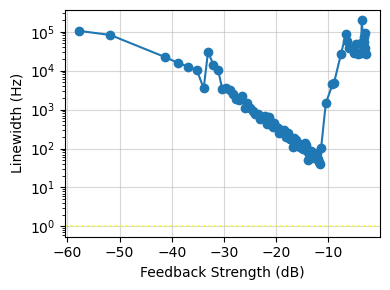

Plot saved successfully to:
C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official\linewidth_vs_feedback_Hz.png


: 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. User Settings & File Paths
# -----------------------------------------------------------------------------
folder_path = r"C:\Users\josep\Documents\MRes mini-project 2\Figures\coherence_collapse\Official"
summary_path = os.path.join(folder_path, "summary_linewidth_vs_coupling.csv")
npz_path = os.path.join(folder_path, "linewidth_and_psd_coarse.npz")

# -----------------------------------------------------------------------------
# 2. Data Loading (Tries summary CSV first, falls back to .npz)
# -----------------------------------------------------------------------------
if os.path.isfile(summary_path):
    print(f"Loading summary from: {summary_path}")
    df = pd.read_csv(summary_path)
    
    # Filter valid non-NaN rows
    valid_mask = np.isfinite(df["feedback_strength_dB"]) & np.isfinite(df["linewidth_MHz"])
    df_valid = df[valid_mask].copy()
    
    # Sort by feedback strength for a clean continuous line
    df_valid = df_valid.sort_values(by="feedback_strength_dB")
    
    feedback_dB = df_valid["feedback_strength_dB"].values
    linewidth_Hz = df_valid["linewidth_MHz"].values * 1e6  # Convert MHz to Hz

elif os.path.isfile(npz_path):
    print(f"Loading from NPZ cache: {npz_path}")
    data = np.load(npz_path)
    
    sort_idx = np.argsort(data["feedback_sorted"])
    feedback_dB = data["feedback_sorted"][sort_idx]
    linewidth_Hz = data["linewidth_sorted"][sort_idx] * 1e6  # Convert MHz to Hz

else:
    raise FileNotFoundError(f"Could not find summary CSV or NPZ file in: {folder_path}")

# -----------------------------------------------------------------------------
# 3. Plotting Linewidth (Hz) vs Feedback Strength (dB)
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4, 3))

# Main curve plot
ax.plot(feedback_dB, linewidth_Hz, "o-", label="QD DFB Laser")

# Formatting Axes
ax.set_yscale("log")
ax.set_xlabel("Feedback Strength (dB)")
ax.set_ylabel("Linewidth (Hz)")

# Optional styling matching typical paper layouts
ax.grid(True,alpha=0.5)

# Add a light indicator line for 1 Hz if your linewidth drops into sub-Hz
if np.min(linewidth_Hz) < 100:
    ax.axhline(1.0, color="yellow", linestyle=":", alpha=0.7, label="1 Hz benchmark")

plt.tight_layout()

# Save output figure
output_image = os.path.join(folder_path, "linewidth_vs_feedback_Hz.png")
plt.savefig(output_image, dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved successfully to:\n{output_image}")